# Con đường phục hồi lợi nhuận

Waterfall chart theo phong cách executive consulting, mô phỏng cách doanh nghiệp có thể thu hẹp khoảng hụt lợi nhuận thông qua nhiều đòn bẩy chiến lược phối hợp.

**Lưu ý:** Các giá trị trong biểu đồ là chỉ số minh họa để phục vụ storytelling và prescriptive analytics. Đây không phải số liệu kế toán hay forecast output từ model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

In [2]:
def configure_font():
    candidates = [
        Path("C:/Windows/Fonts/arial.ttf"),
        Path("C:/Windows/Fonts/segoeui.ttf"),
        Path("C:/Windows/Fonts/calibri.ttf"),
    ]
    for path in candidates:
        if path.exists():
            font_manager.fontManager.addfont(str(path))
            plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(path)).get_name()
            return
    plt.rcParams["font.family"] = "DejaVu Sans"


def resolve_output_dir():
    cwd = Path.cwd()
    if cwd.name == "report_visuals":
        return cwd
    candidate = cwd / "ai_eda" / "report_visuals"
    if candidate.exists():
        return candidate
    return cwd


configure_font()
OUT_DIR = resolve_output_dir()
OUT_DIR

WindowsPath('d:/Code/Datathon 2026/Datathon-2026-Inlier/ai_eda/report_visuals')

In [3]:
labels = [
    'Khoảng hụt\nlợi nhuận hiện tại',
    'Tối ưu\nkhuyến mãi',
    'Giảm áp lực\ntồn kho',
    'Phục hồi\nchuyển đổi',
    'Cải thiện\ncơ cấu sản phẩm',
    'Giảm áp lực\ngiảm giá',
    'Lợi nhuận\ncó thể phục hồi',
]

# Chỉ số minh họa: khoảng hụt so với năm đỉnh = 0, trạng thái hiện tại = -100.
# Các bước dương thể hiện mức đóng góp giả định của từng strategic lever.
contributions = [-100, 24, 16, 22, 18, 14]
final_value = sum(contributions)
values = contributions + [final_value]

colors = {
    "start": "#566B5F",
    "lever": "#8FB79C",
    "major": "#2F6B4F",
    "final": "#123D2A",
    "connector": "#B8C5BC",
    "grid": "#E7ECE8",
    "text": "#1E2A23",
    "muted": "#637267",
}

In [4]:
def create_profit_recovery_waterfall(labels, values, contributions, final_value, colors):
    fig, ax = plt.subplots(figsize=(15.8, 8.6), dpi=180)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x = np.arange(len(labels))
    bar_w = 0.62
    cum = 0
    bottoms, heights, end_levels = [], [], []

    for i, val in enumerate(values):
        if i == 0:
            bottom = 0
            height = val
            cum = val
        elif i == len(values) - 1:
            bottom = 0
            height = final_value
        else:
            bottom = cum
            height = val
            cum += val
        bottoms.append(bottom)
        heights.append(height)
        end_levels.append(bottom + height)

    for i, (bottom, height) in enumerate(zip(bottoms, heights)):
        if i == 0:
            color = colors["start"]
        elif i == len(values) - 1:
            color = colors["final"]
        elif i in {1, 3}:
            color = colors["major"]
        else:
            color = colors["lever"]
        ax.bar(
            x[i],
            height,
            bottom=bottom,
            width=bar_w,
            color=color,
            edgecolor="white",
            linewidth=1.4,
            zorder=3,
        )

    for i in range(len(labels) - 2):
        level = end_levels[i]
        ax.plot(
            [x[i] + bar_w / 2, x[i + 1] - bar_w / 2],
            [level, level],
            color=colors["connector"],
            lw=1.2,
            zorder=2,
        )

    ax.axhline(0, color="#B9C2BB", lw=1.1, zorder=1)

    for i, (bottom, height) in enumerate(zip(bottoms, heights)):
        if i == 0:
            ax.text(
                x[i],
                bottom + height / 2,
                "-100",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color="white",
            )
        elif i == len(values) - 1:
            ax.text(
                x[i],
                final_value - 4,
                f"{final_value:+.0f}",
                ha="center",
                va="top",
                fontsize=12,
                fontweight="bold",
                color="white",
            )
            ax.text(
                x[i],
                final_value + 5,
                "phục hồi 94 điểm",
                ha="center",
                va="bottom",
                fontsize=10.5,
                color=colors["final"],
                fontweight="bold",
            )
        else:
            ax.text(
                x[i],
                bottom + height + 3,
                f"+{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=11.5,
                fontweight="bold",
                color=colors["text"],
            )

    ax.text(
        1.05,
        12,
        "ĐÒN BẨY THƯƠNG MẠI",
        fontsize=9.5,
        color=colors["muted"],
        fontweight="bold",
        ha="left",
        va="center",
    )
    ax.plot([0.75, 4.35], [8, 8], color=colors["grid"], lw=1.1)
    ax.text(
        2.0,
        -119,
        "CẢI THIỆN VẬN HÀNH",
        fontsize=9.5,
        color=colors["muted"],
        fontweight="bold",
        ha="left",
        va="center",
    )
    ax.plot([1.75, 5.35], [-114, -114], color=colors["grid"], lw=1.1)

    ax.annotate(
        "Tối ưu khuyến mãi\ngiảm bào mòn biên lợi nhuận",
        xy=(1, -76),
        xycoords="data",
        xytext=(0.55, -47),
        textcoords="data",
        arrowprops=dict(arrowstyle="-", color=colors["connector"], lw=1.0),
        fontsize=9.5,
        color=colors["muted"],
        ha="left",
        va="center",
    )
    ax.annotate(
        "Giảm tồn kho giúp hạn chế\náp lực xả hàng và markdown",
        xy=(2, -60),
        xycoords="data",
        xytext=(2.55, -86),
        textcoords="data",
        arrowprops=dict(arrowstyle="-", color=colors["connector"], lw=1.0),
        fontsize=9.5,
        color=colors["muted"],
        ha="left",
        va="center",
    )
    ax.annotate(
        "Phục hồi chuyển đổi\ntăng hiệu quả monetization",
        xy=(3, -38),
        xycoords="data",
        xytext=(3.45, -23),
        textcoords="data",
        arrowprops=dict(arrowstyle="-", color=colors["connector"], lw=1.0),
        fontsize=9.5,
        color=colors["muted"],
        ha="left",
        va="center",
    )

    fig.text(
        0.055,
        0.93,
        "Con đường phục hồi lợi nhuận",
        fontsize=23,
        fontweight="bold",
        color=colors["text"],
        ha="left",
    )
    fig.text(
        0.055,
        0.885,
        "Lợi nhuận có thể cải thiện đáng kể khi phối hợp các hành động vận hành và thương mại.",
        fontsize=12.5,
        color=colors["muted"],
        ha="left",
    )

    fig.text(
        0.78,
        0.925,
        "Thông điệp điều hành",
        fontsize=10.5,
        fontweight="bold",
        color=colors["final"],
        ha="left",
    )
    fig.text(
        0.78,
        0.875,
        "Phục hồi lợi nhuận không đến từ\nmột nguyên nhân đơn lẻ; hiệu quả đến\ntừ phối hợp khuyến mãi, tồn kho,\nchuyển đổi và cơ cấu sản phẩm.",
        fontsize=10.0,
        color=colors["muted"],
        ha="left",
        linespacing=1.35,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10.5, color=colors["text"])
    ax.set_ylabel("Chỉ số tác động lợi nhuận\n(khoảng hụt so với đỉnh = 0)", fontsize=10.5, color=colors["muted"])
    ax.set_ylim(-125, 20)
    ax.set_yticks([-100, -75, -50, -25, 0])
    ax.tick_params(axis="y", labelsize=9.5, colors=colors["muted"], length=0)
    ax.tick_params(axis="x", length=0, pad=12)
    ax.yaxis.grid(True, color=colors["grid"], linewidth=0.8)
    ax.xaxis.grid(False)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#D8DED9")

    fig.text(
        0.055,
        0.045,
        "Minh họa prescriptive analytics. Giá trị là chỉ số tác động lợi nhuận nhằm truyền tải strategic recovery levers, không phải số liệu kế toán hay forecast output.",
        fontsize=8.8,
        color="#7A867D",
        ha="left",
    )

    plt.subplots_adjust(left=0.075, right=0.965, top=0.80, bottom=0.18)
    return fig, ax

d:\Code\Datathon 2026\Datathon-2026-Inlier\ai_eda\report_visuals\profit_recovery_waterfall.png
d:\Code\Datathon 2026\Datathon-2026-Inlier\ai_eda\report_visuals\profit_recovery_waterfall.svg


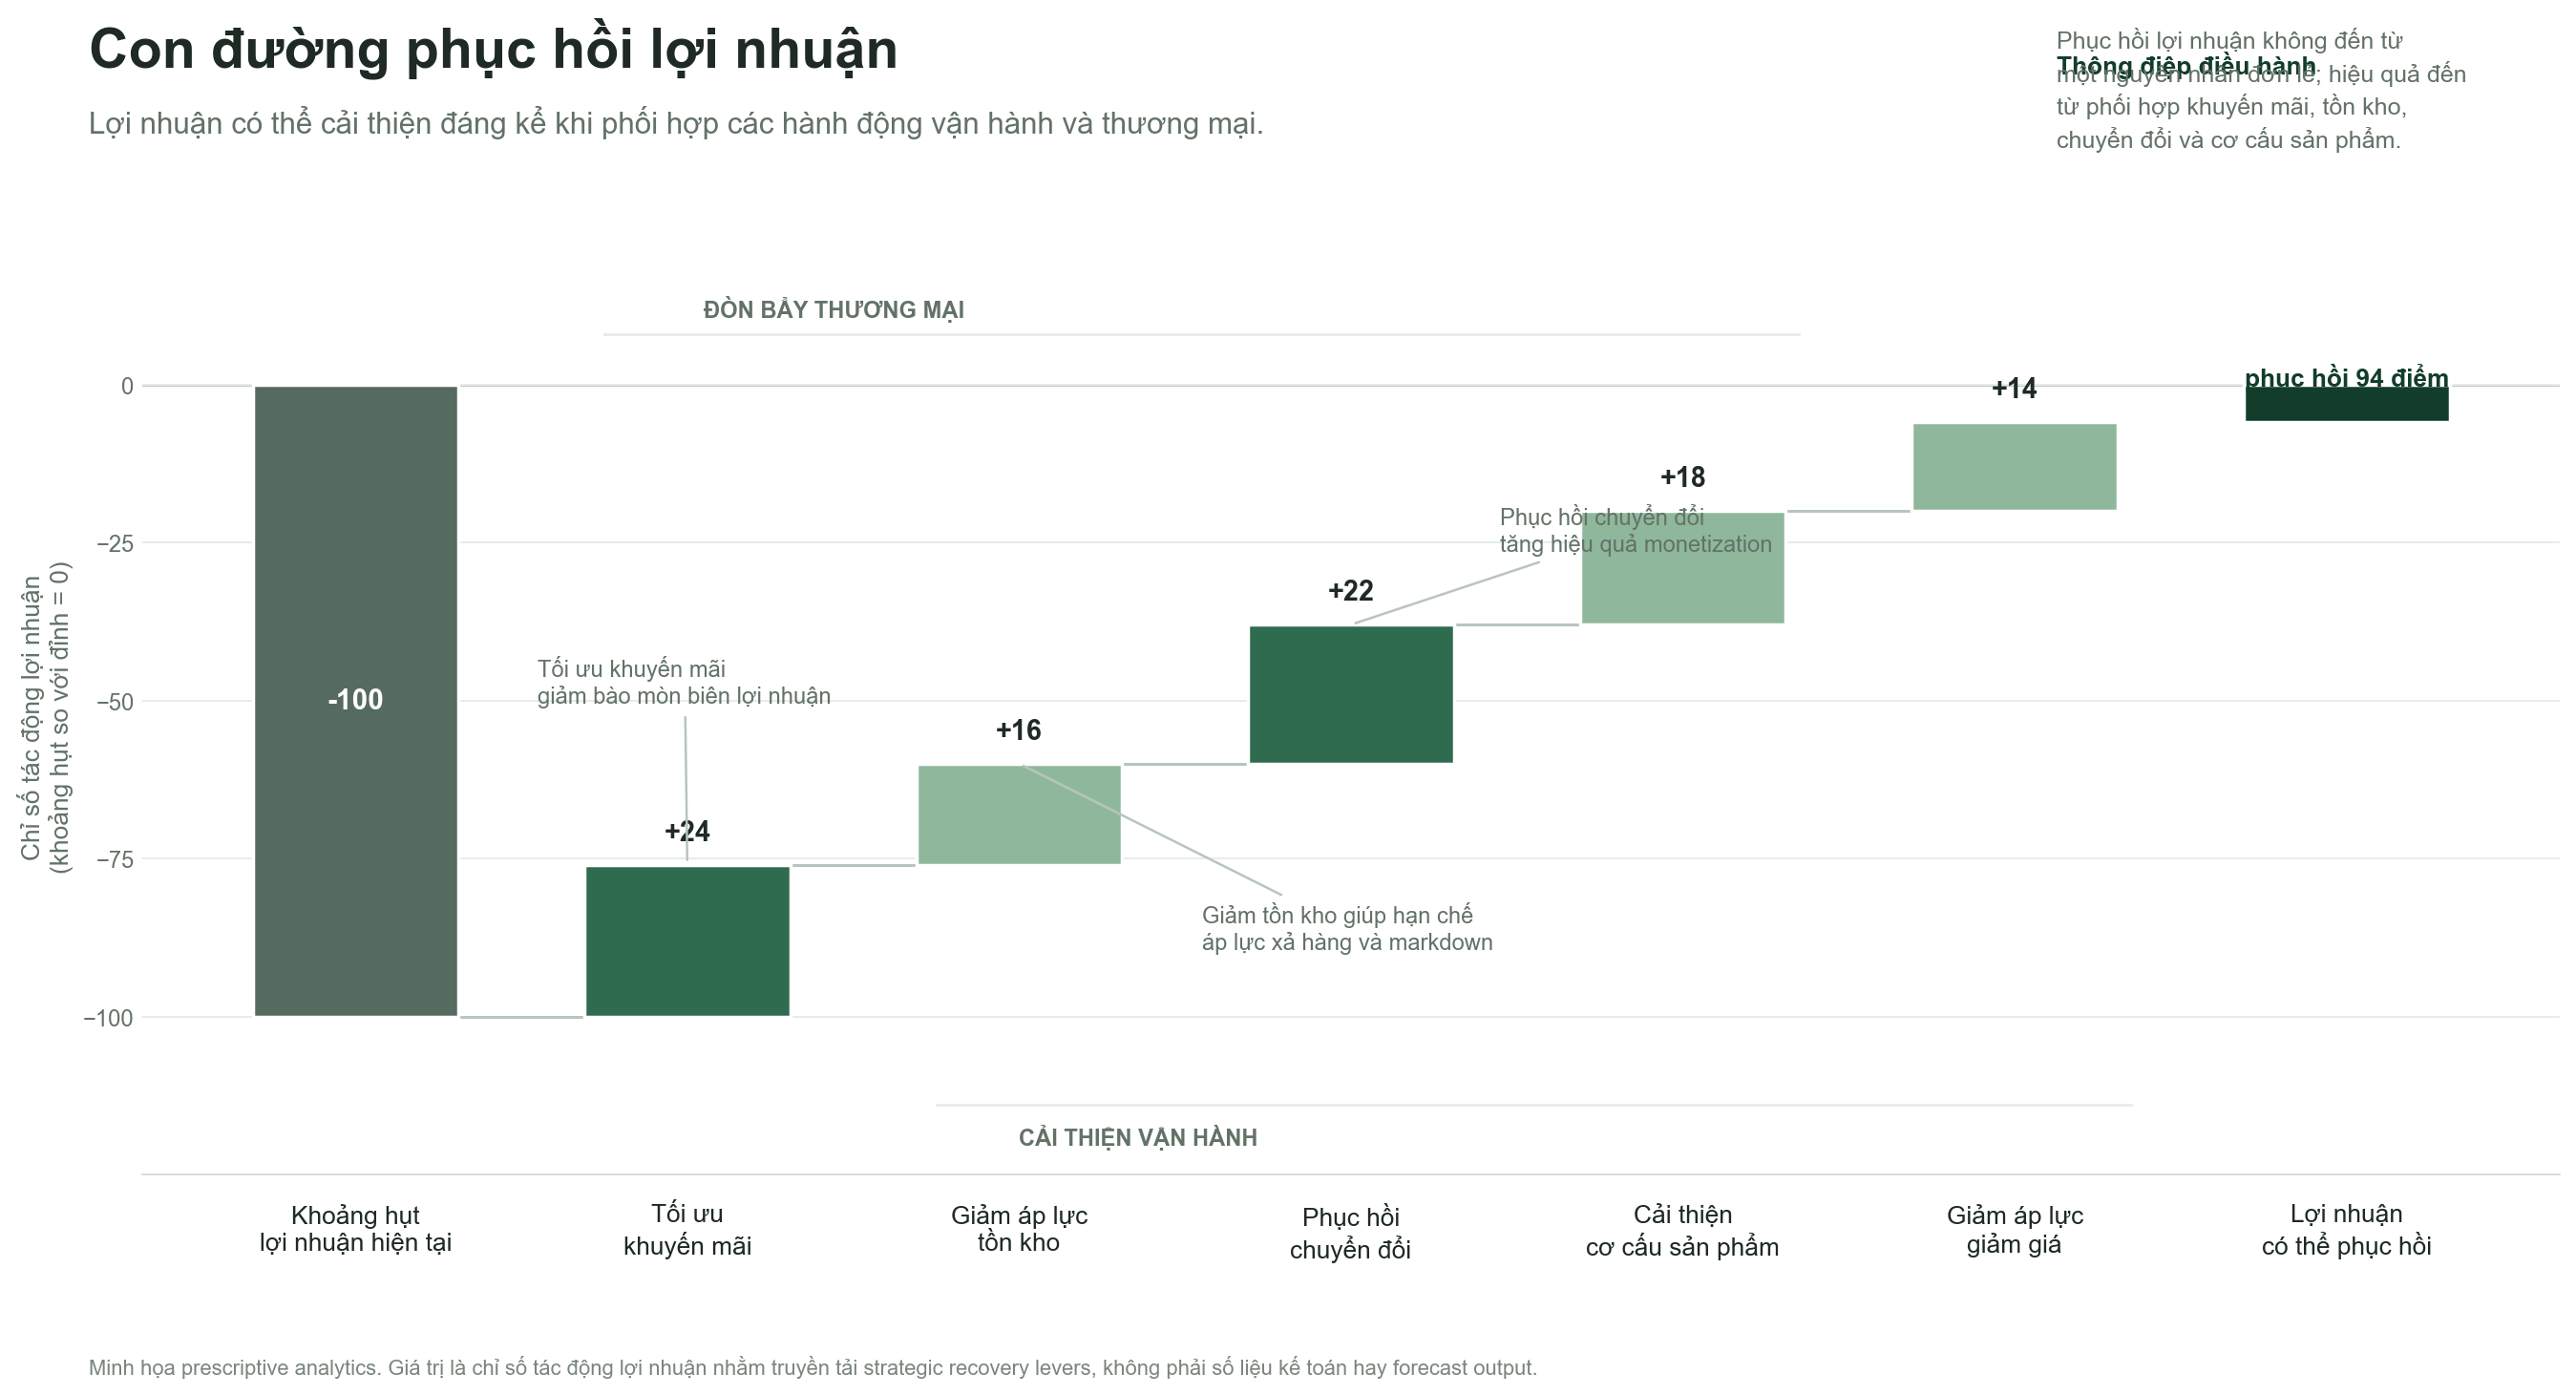

In [5]:
fig, ax = create_profit_recovery_waterfall(labels, values, contributions, final_value, colors)

png_path = OUT_DIR / "profit_recovery_waterfall.png"
svg_path = OUT_DIR / "profit_recovery_waterfall.svg"
fig.savefig(png_path, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")

print(png_path)
print(svg_path)
plt.show()